# Visualizing Urca shell

In [1]:
import mesa_reader as mr

## Load the MESA model

read in profile from lab 3

In [2]:
model = mr.MesaData("lab3/profile2.data")

In [3]:
rho = 10.0**model.logRho
T = 10.0**model.logT

In [4]:
import matplotlib.pyplot as plt

## Build a network

In [5]:
import pynucastro as pyna
from pynucastro import mesa_utils

In [6]:
nuclei = mesa_utils.get_nuclei(model)

In [7]:
net = pyna.network_helper(nuclei)

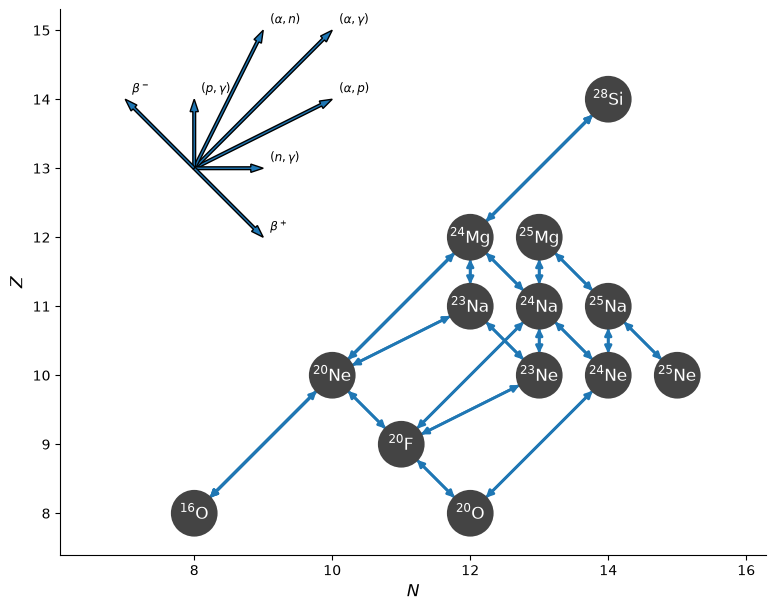

In [8]:
fig = net.plot(legend_coord=(13, 8))

## Compute the curve for electron-capture = beta-decay

We need the $Y_e$, so we'll take the composition from the surface of the model---it doesn't matter too much

In [9]:
mesa_model = mesa_utils.MesaModel(model)

In [10]:
state = mesa_model.get_zone_data(0)

In [16]:
comp = state.comp
comp.ye

0.49871304347826084

We'll use Brent's method for root-finding.  There will be a very tight range
where we get a shell, outside of which the root-finding will fail, so we'll
use NaNs to indicate these failures.

This function will take the EC and beta-decay rates and return the $\rho(T)$
curve for the shell, $\lambda_\mathrm{ec} = \lambda_{\beta\mathrm{\mbox{-}decay}}$

In [17]:
import numpy as np
from scipy.optimize import brentq

In [18]:
def find_urca_shell(r_ec, r_beta):

    # grid of density to search
    rhos = np.logspace(8.5, 10.0, 1000)
    Ts = np.zeros_like(rhos)
    
    for i, r in enumerate(rhos):
        try:
            # we need a temperature bound to bracket the search
            Ts[i] = brentq(lambda _T: (r_beta.eval(_T, rho=r, comp=comp) -
                                       r_ec.eval(_T, rho=r, comp=comp)),
                           2.e7, 3.e9)
        except ValueError:
            Ts[i] = np.nan

    idx = np.where(~np.isnan(Ts))[0]
    T_urca = Ts[idx]
    rho_urca = rhos[idx]
    return rho_urca, T_urca

### Na23-Ne23 shell

In [19]:
r_ec = net.get_rate_by_name("na23(,)ne23")
r_beta = net.get_rate_by_name("ne23(,)na23")

In [20]:
rho_urca_23, T_urca_23 = find_urca_shell(r_ec, r_beta)

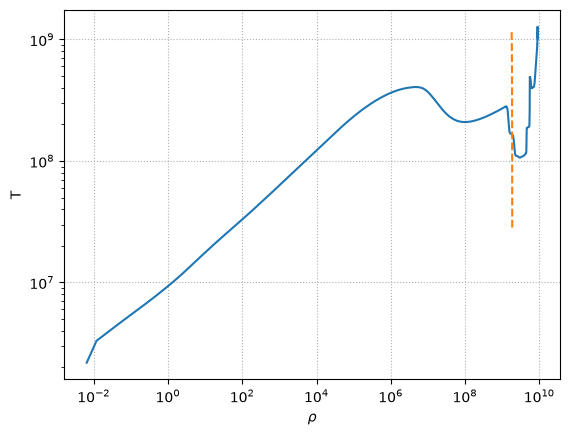

In [21]:
fig, ax = plt.subplots()
ax.loglog(rho, T)
ax.loglog(rho_urca_23, T_urca_23, ls="--", label=r"${}^{23}\mathrm{Na}-{}^{23}\mathrm{Ne}$ shell")
ax.set_xlabel(r"$\rho$")
ax.set_ylabel("T")
ax.grid(ls=":")

### Na25-Ne25 shell

In [22]:
r_ec = net.get_rate_by_name("na25(,)ne25")
r_beta = net.get_rate_by_name("ne25(,)na25")

In [23]:
rho_urca_25, T_urca_25 = find_urca_shell(r_ec, r_beta)

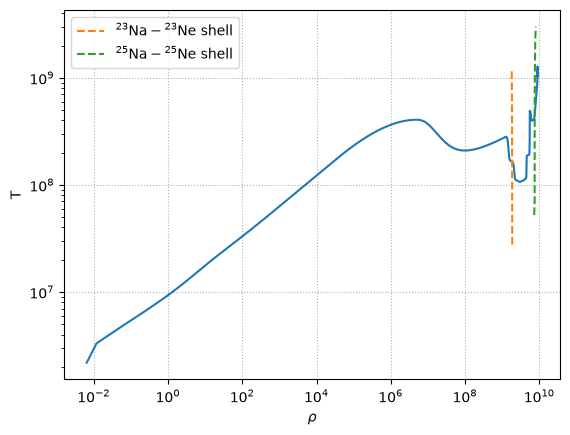

In [24]:
ax.loglog(rho_urca_25, T_urca_25, ls="--", label=r"${}^{25}\mathrm{Na}-{}^{25}\mathrm{Ne}$ shell")
ax.legend()
fig